# MovieGraphs Dataset Tutorial
- Please refer the paper for more details: https://arxiv.org/abs/1712.06761
- This is a tutorial made for using MovieGraphs dataset
- All the rights of the dataset are reserved by the authors

## Install dependencies
- The code is setup to work with python 3.10 and may not work with higher versions
- Please install the dependencies using the requirements at path `mg_all/mg_new/requirements.txt`.
    - You can use `pip install -r requirements.txt` to install the dependencies.
```

In [1]:
import json
import pickle
import matplotlib.pyplot as plt

# Local imports
%load_ext autoreload
%autoreload 2


In [2]:
# Load all annotations
with open('all_movies.pkl', 'rb') as fid:
    all_mg = pickle.load(fid, encoding='latin1')

In [3]:
mg = all_mg['tt0120338']
cg = mg.clip_graphs[247]
cg.video

{'movie': 'tt0120338',
 'fname': ['scene-248.ss-1270.es-1276.mp4'],
 'scene': [248],
 'ss': 1270,
 'es': 1276}

In [4]:
with open('../split.json', 'r') as fid:
    splits = json.load(fid)

In [5]:
cg.video

{'movie': 'tt0120338',
 'fname': ['scene-248.ss-1270.es-1276.mp4'],
 'scene': [248],
 'ss': 1270,
 'es': 1276}

In [6]:
def get_biggest_ts(cg):
    node_ids = cg.get_node_ids_of_type(('time'))
    last_end_time = 0.
    for node_id in node_ids:
        if cg.G.node[node_id]['origtext'] == 'Time': continue
        if 'end' not in cg.G.node[node_id]: continue
        if not cg.G.node[node_id]['end']: continue
        this_last = cg.G.node[node_id]['end']
        if this_last > last_end_time:
            last_end_time = this_last
    return last_end_time

In [7]:
clip = cg
node_ids = clip.get_node_ids_of_type(('summary', 'interaction'))
for node_id in node_ids:
    for neighbor in clip.G.neighbors(node_id):
        if clip.G.node[neighbor]['type'] == 'time':
            time_node = clip.G.node[neighbor]
            print(time_node)


{'name': '0:23-0:41.5', 'start': 23, 'end': 41.5, 'origtext': '0:23-0:41.5', 'type': 'time', 'pos': (444.3333435058594, 246)}
{'name': '0:38-0:41.5', 'start': 38, 'end': 41.5, 'origtext': '0:38-0:41.5', 'type': 'time', 'pos': (169.33334350585938, 232)}
{'name': '0:23-0:28', 'start': 23, 'end': 28, 'origtext': '0:23-0:28', 'type': 'time', 'pos': (375.3333435058594, 42)}
{'name': '0:04-0:13', 'start': 4, 'end': 13, 'origtext': '0:04-0:13', 'type': 'time', 'pos': (113.33334350585938, 346)}
{'name': '0:00-0:03', 'start': 0, 'end': 3, 'origtext': '0:00-0:03', 'type': 'time', 'pos': (114.33334350585938, 17)}


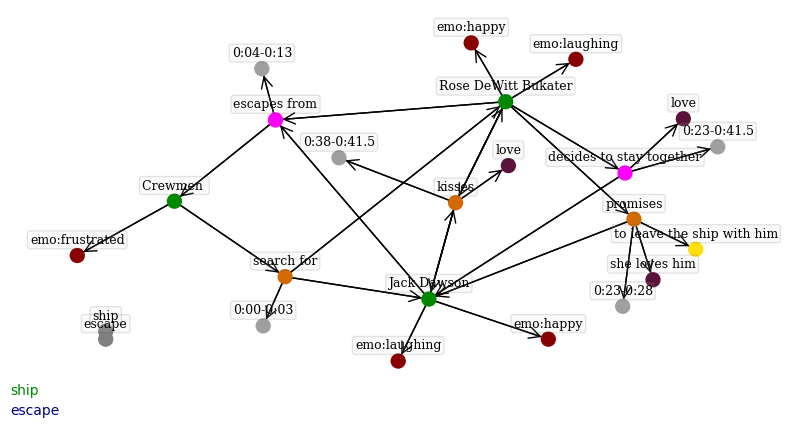

In [9]:
plt.figure(figsize=(10, 5))
cg.visualize_graph()


In [10]:
mg.visualize_all_graphs()